# 033 — Evaluation: unet variants (residual head, unet_v2, restormer, dilated)

Quantitative comparison of `unet_residual`, `unet_v2`, `unet_restormer`, `unet_dilated`, and `unet_v2_dilated` — architectural variants of `unet` — against `unet` itself as the direct baseline, on the held-out test set. `unet_residual` (`020_training.ipynb`) shares `unet`'s backbone and parameter count exactly and, at the default `combined_loss`, its loss too — so the `unet` vs. `unet_residual` pair isolates the output head (signed `tanh` residual over `mean(R, G, B)`, `scripts/unet_residual.py`). `unet_dilated`/`unet_v2_dilated` (`fixing.md` #7, Round 3) replace the plain bottleneck with a dilated ASPP block (`scripts/aspp.py`) — compare each against its non-dilated counterpart (`unet_dilated` vs. `unet`, `unet_v2_dilated` vs. `unet_v2`), not just against the table as a whole. Same block layout as `030`/`031`/`032` — see `030_evaluation.ipynb`'s title cell for the full table of companion notebooks.


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.


In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check.


In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.trainer import load_model

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Build the test dataset

Artwork-and-mockups split, same as the notebook that trained these checkpoints — required so the reported test metrics are on data none of them saw during training or validation.


In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
_, _, test_pairs = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

test_ds = build_dataset(
    test_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)
print(f"Test pairs: {len(test_pairs)} | Test batches: {len(test_ds)}")

Test pairs: 135 | Test batches: 17


2026-08-27 08:16:49.079046: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-27 08:16:49.079073: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-27 08:16:49.079078: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-27 08:16:49.079089: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 08:16:49.079101: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Evaluate unet, unet_residual, unet_v2, unet_restormer, unet_dilated, unet_v2_dilated

`unet` is included as the baseline the variants are each meant to be compared against. All three load from `models/deterministic/<arch>/best_model.keras`.


In [4]:
ARCHS = ["unet", "unet_residual", "unet_v2", "unet_restormer", "unet_dilated", "unet_v2_dilated"]
MODEL_DIR = settings.MODELS_DIR / "deterministic"
results: dict = {}

for arch in ARCHS:
    try:
        model = load_model(
            arch,
            model_dir=MODEL_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    print(f"Evaluating {arch}...")
    metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
    results[arch] = metrics
    print(f"  {arch}: { {k: f'{v:.4f}' for k, v in metrics.items()} }")

Evaluating unet...


2026-08-27 08:16:50.132836: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  unet: {'loss': '0.3338', 'mae': '0.1563', 'psnr': '16.4995', 'ssim': '0.5447'}
Evaluating unet_v2...
  unet_v2: {'loss': '0.3322', 'mae': '0.1504', 'psnr': '16.7452', 'ssim': '0.5595'}
Evaluating unet_restormer...
  unet_restormer: {'loss': '0.3333', 'mae': '0.1556', 'psnr': '16.5437', 'ssim': '0.5477'}
Evaluating unet_dilated...
  unet_dilated: {'loss': '0.3311', 'mae': '0.1571', 'psnr': '16.4494', 'ssim': '0.5446'}
Evaluating unet_v2_dilated...
  unet_v2_dilated: {'loss': '0.3382', 'mae': '0.1461', 'psnr': '16.8025', 'ssim': '0.5556'}


## 3. Comparison table


In [5]:
if results:
    col_w = 24
    headers = ["architecture"] + list(next(iter(results.values())).keys())
    print("".join(h.ljust(col_w) for h in headers))
    print("-" * (col_w * len(headers)))
    for arch, metrics in results.items():
        row = [arch] + [f"{v:.4f}" for v in metrics.values()]
        print("".join(c.ljust(col_w) for c in row))

architecture            loss                    mae                     psnr                    ssim                    
------------------------------------------------------------------------------------------------------------------------
unet                    0.3338                  0.1563                  16.4995                 0.5447                  
unet_v2                 0.3322                  0.1504                  16.7452                 0.5595                  
unet_restormer          0.3333                  0.1556                  16.5437                 0.5477                  
unet_dilated            0.3311                  0.1571                  16.4494                 0.5446                  
unet_v2_dilated         0.3382                  0.1461                  16.8025                 0.5556                  


## 4. Bar chart comparison


/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_15467/444814583.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_15467/444814583.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_15467/444814583.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_15467/444814583.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

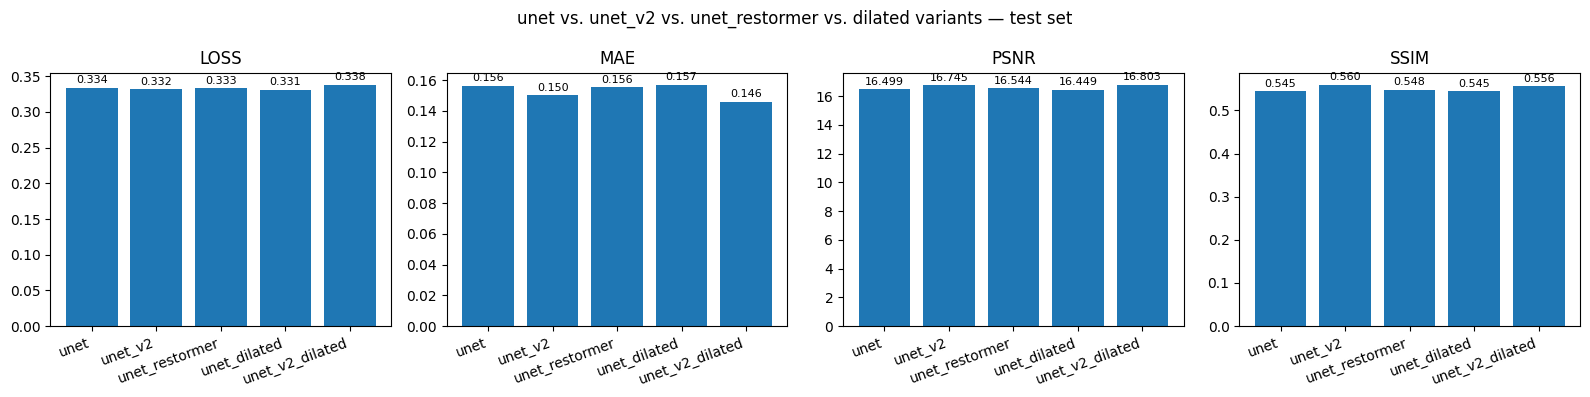

In [6]:
if results:
    metric_keys = list(next(iter(results.values())).keys())
    n = len(metric_keys)
    archs = list(results.keys())
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle("unet vs. unet_v2 vs. unet_restormer vs. dilated variants — test set")
    for ax, key in zip(axes, metric_keys):
        vals = [results[a][key] for a in archs]
        bars = ax.bar(archs, vals)
        ax.set_title(key.upper())
        ax.set_xticklabels(archs, rotation=20, ha="right")
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()